## 产生Bound State 纯随机初始化 get_ansatz

In [ ]:
import torch
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns

# ================= 配置 =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64) 
np.set_printoptions(threshold=sys.maxsize, linewidth=200, precision=6, suppress=True)
print(f"Running on: {device}")

TASK_DIM = 7           # 量子比特维度 (2-10)
TASK_RANK = 4          # Ansatz秩
TASK_MAX_ATTEMPTS = 20 # 最大尝试次数

# ================= 函数 =================
def get_ansatz(dim, rank):
    real = torch.randn(dim * dim, rank, device=device)
    imag = torch.randn(dim * dim, rank, device=device)
    A = torch.complex(real, imag)
    A.requires_grad = True
    return A

def get_rho(A):                # Cholesky decomposition构造密度矩阵
    rho_un = A @ A.mH
    trace = torch.trace(rho_un) + 1e-16 # 防止trace为0
    return rho_un / trace

def partial_transpose_torch(rho, dim):          # 计算部分转置，判断量子态是否为PPT态
    rho_reshaped = rho.view(dim, dim, dim, dim)
    rho_pt = rho_reshaped.permute(0, 3, 2, 1).contiguous()
    return rho_pt.view(dim * dim, dim * dim)

def get_metrics(rho, dim):
    # PPT最小特征值
    pt = partial_transpose_torch(rho, dim)
    min_ppt = torch.min(torch.linalg.eigvalsh(pt))
    # 调整CCN范数
    rho_reshaped = rho.view(dim, dim, dim, dim)
    rho_r = rho_reshaped.permute(0, 2, 1, 3).contiguous().view(dim*dim, dim*dim)
    r_norm = torch.linalg.matrix_norm(rho_r, ord='nuc')
    return min_ppt, r_norm

# ================= 修复临界NPT态为PPT态 =================
def try_repair_state(rho_np, dim):
    """
    尝试通过混合白噪声将微弱 NPT 的态修复为 PPT。
    rho_new = (1-p) * rho + p * (I/d^2)
    """
    print("   >>> 启动自动修复程序...")

    d2 = dim * dim
    I = np.eye(d2) / d2
    
    # 计算最小特征值
    rho_tensor = rho_np.reshape(dim, dim, dim, dim)
    rho_pt = rho_tensor.transpose(0, 3, 2, 1).reshape(d2, d2)
    min_eig = np.min(np.linalg.eigvalsh(rho_pt))
    
    if min_eig >= 0:
        return rho_np # 最小特征值大于等于0，不需要修复
    
    # 只要混合一点点白噪声，就能把负特征值拉正
    # p 的估算公式： p > |min_eig| * d^2 
    p_needed = abs(min_eig) * d2 * 1.5  # 多加50%余量以防万一
    
    print(f"   >>> 估算需要的白噪声比例 p = {p_needed:.8f}")
    
    # 尝试修复
    rho_repaired = (1 - p_needed) * rho_np + p_needed * I
    
    return rho_repaired

# ================= 生成束缚纠缠态 =================
def generate_be_robust(dim=TASK_DIM, rank=TASK_RANK, max_attempts=TASK_MAX_ATTEMPTS):
    print(f"\n 目标: 构造 Dim {dim}x{dim}, Rank {rank} ")
    
    for attempt in range(1, max_attempts + 1):
        A = get_ansatz(dim, rank)
        optimizer = torch.optim.Adam([A], lr=0.04)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=500)
        
        print(f"\n[Attempt {attempt}]")
        
        # 稍微放宽判定标准，捕捉“差一点点”的态
        best_candidate = None
        best_candidate_score = -1.0
        
        total_steps = 6000
        start_target = 1.01
        end_target = 1.0005 # 稍微高一点，留给修复用
        
        for i in range(total_steps):
            optimizer.zero_grad()
            rho = get_rho(A)
            min_pt, r_norm = get_metrics(rho, dim)
            
    
            # 如果 PPT 稍微负一点点 (>-0.001) 且 纠缠度还不错 (>1.002)
            # 存下来，最后尝试修复
            if min_pt.item() > -0.001 and r_norm.item() > 1.002:
                # 评分标准：PPT越接近0越好，Norm越大越好
                score = r_norm.item() - 100 * abs(min_pt.item())
                if score > best_candidate_score:
                    best_candidate_score = score
                    best_candidate = rho.detach().cpu().numpy()

            # --- 损失函数 ---
            decay = np.exp(-5.0 * i / total_steps)
            current_target = end_target + (start_target - end_target) * decay
            
            loss = 0
            ppt_weight = 1000.0 + (i / total_steps) * 9000.0
            
            if min_pt < 0:
                loss += torch.nn.functional.softplus(-min_pt * ppt_weight)
            else:
                loss += -min_pt * 0.1

            if r_norm < current_target:
                diff = current_target - r_norm
                ent_weight = 100.0 + (i / total_steps) * 400.0
                loss += diff * ent_weight
            
            loss += 0.0001 * torch.norm(A)
            
            loss.backward()
            optimizer.step()
            scheduler.step(loss)
            
            # 完美成功判定
            if min_pt.item() > -1e-8 and r_norm.item() > 1.00001:
                print(f"\n [PERFECT HIT] Step {i}")
                return rho.detach().cpu().numpy()
            
            if i % 1000 == 0:
                print(f"   Step {i:4d} | Target: {current_target:.5f} | PPT: {min_pt.item():.6f} | Norm: {r_norm.item():.6f}")
        
        # 循环结束，如果没有完美结果，尝试修复最佳候选者
        if best_candidate is not None:
            print("   >>> 尝试修复最佳候选者...")
            rho_fixed = try_repair_state(best_candidate, dim)
            
            # 验证修复结果
            rho_t = torch.tensor(rho_fixed, device=device)
            m_ppt, m_norm = get_metrics(rho_t, dim)
            
            print(f"   >>> 修复后: PPT={m_ppt.item():.8f}, Norm={m_norm.item():.8f}")
            
            if m_ppt.item() > -1e-15 and m_norm.item() > 1.0:
                print("🎉 [REPAIR SUCCESS] 成功修复为束缚纠缠态！")
                return rho_fixed
            else:
                print("   >>> 修复后纠缠度丢失，继续尝试...")
        else:
            print("   >>> 没有找到有修复价值的候选者。")

    print("\n All attempts failed.")
    return None

# ================= 运行 =================

rho_final = generate_be_robust(dim=TASK_DIM, rank=TASK_RANK, max_attempts=TASK_MAX_ATTEMPTS) 

if rho_final is not None:
    print("\n" + "="*60)
    print(" 最终结果 ")
    print("="*60)
    
    rho_np = rho_final
    
    # 打印矩阵供复制
    print("rho = np.array(")
    print(np.array2string(rho_np, separator=', '))
    print(")")
    
    # 最终严格物理验证
    dim = TASK_DIM
    rank = TASK_RANK
    
    # PPT 验证
    rho_ts = rho_np.reshape(dim, dim, dim, dim)
    rho_pt = rho_ts.transpose(0, 3, 2, 1).reshape(dim*dim, dim*dim)
    min_eig = np.min(np.linalg.eigvalsh(rho_pt))
    
    # 纠缠验证
    rho_r = rho_ts.transpose(0, 2, 1, 3).reshape(dim*dim, dim*dim)
    r_norm = np.sum(np.linalg.svd(rho_r, compute_uv=False))
    
    # Rank 验证
    s = np.linalg.svd(rho_np, compute_uv=False)
    # 因为修复过程加了满秩的白噪声，Rank 会变成 Full Rank (16)
    # 但白噪声极其微小 (1e-6级别)，所以主要成分的 Rank 还是 4
    # 我们看 "显著奇异值"
    eff_rank = np.sum(s > 1e-4) 
    
    print("-" * 30)
    print(f"1. PPT Check (Min Eig) : {min_eig:.9f}  [{'PASS' if min_eig > -1e-9 else 'FAIL'}]")
    print(f"2. Entanglement (Norm) : {r_norm:.9f}  [{'PASS' if r_norm > 1.0 else 'FAIL'}]")
    print(f"3. Significant Rank    : {eff_rank}          (Base Rank was {rank})")
    print("-" * 30)
    
    if min_eig > -1e-9 and r_norm > 1.0:
        print("结论: 这是一个有效的束缚纠缠态。")
    else:
        print("结论: 数据仍有瑕疵。")

# 确保 rho_final 是 numpy 格式
if isinstance(rho_final, torch.Tensor):
    rho_np = rho_final.detach().cpu().numpy()
else:
    rho_np = rho_final

# 文本打印
print("\n" + "="*50)
print("密度矩阵数值展示")
print("="*50)

# 设置打印选项
np.set_printoptions(threshold=np.inf, linewidth=200, precision=4, suppress=True)

# 打印实部
print("--- 实部 (Real Part) ---")
print(rho_np.real)

# 打印虚部
if np.max(np.abs(rho_np.imag)) > 1e-5:
    print("\n--- 虚部 (Imaginary Part) ---")
    print(rho_np.imag)
else:
    print("\n(虚部几乎为0，忽略不计)")


# 可视化 (Cityscape/Heatmap)
plt.figure(figsize=(12, 5))

# 实部热力图
plt.subplot(1, 2, 1)
sns.heatmap(rho_np.real, cmap="RdBu_r", center=0, square=True)
plt.title(f"Real Part (Dim=4, Rank=4 BE State)\nNorm={1.0049:.5f}")

# 虚部热力图
plt.subplot(1, 2, 2)
sns.heatmap(rho_np.imag, cmap="RdBu_r", center=0, square=True)
plt.title("Imaginary Part")

plt.tight_layout()
plt.show()

# 保存到文件

filename = f"../data/BE_States_Results/BE_State_{TASK_DIM}x{TASK_DIM}_Rank{TASK_RANK}_1.npy"
np.save(filename, rho_np)
print(f"\n 矩阵已保存至: {filename}")
print(f"读取方法: rho = np.load('{filename}')")

#  验证是否为 PPT (再次确认)

def check_ppt(rho):
    dim = int(np.sqrt(rho.shape[0]))
    rho_tensor = rho.reshape(dim, dim, dim, dim)
    # 对第二个子系统 (B) 进行转置 (索引 1, 3)
    rho_pt = rho_tensor.transpose(0, 3, 2, 1).reshape(dim*dim, dim*dim)
    min_eig = np.min(np.linalg.eigvalsh(rho_pt))
    return min_eig

ppt_val = check_ppt(rho_np)
print(f"\n 最终 PPT 检查: Min Eig = {ppt_val:.9f}")
if ppt_val > -1e-6:
    print("✅ 这是一个合格的 PPT 态。")
else:
    print("⚠️ 警告：仍有微小负特征值，可能需要更多白噪声混合。")

ModuleNotFoundError: No module named 'torch'

## 产生 Bound State 混合初始化 Hybrid Ansatz

Running on: cpu

⚡ 启动高维攻坚: Dim 4x4, Rank 4
策略: 全局 Negativity 优化 + 混合初始化 + 长程退火

[Attempt 1/20]
   Step     0 | Target: 1.05000 | PPT_Min: -0.129530 | Norm: 1.689326
   Step  2000 | Target: 1.03358 | PPT_Min: -0.000488 | Norm: 1.033902
   Step  4000 | Target: 1.02258 | PPT_Min: -0.000007 | Norm: 1.037187
   Step  6000 | Target: 1.01520 | PPT_Min: -0.000005 | Norm: 1.051260
   Step  8000 | Target: 1.01025 | PPT_Min: -0.000004 | Norm: 1.076574
   Step 10000 | Target: 1.00694 | PPT_Min: -0.000093 | Norm: 1.105981
   Step 12000 | Target: 1.00472 | PPT_Min: -0.000004 | Norm: 1.123781
   Step 14000 | Target: 1.00323 | PPT_Min: -0.000009 | Norm: 1.134189
   Step 16000 | Target: 1.00223 | PPT_Min: -0.000004 | Norm: 1.140657
   Step 18000 | Target: 1.00156 | PPT_Min: -0.000003 | Norm: 1.145193
   Step 20000 | Target: 1.00111 | PPT_Min: -0.000002 | Norm: 1.148384
   Step 22000 | Target: 1.00081 | PPT_Min: -0.000001 | Norm: 1.150869
   Step 24000 | Target: 1.00061 | PPT_Min: -0.000001 | Norm: 1.15

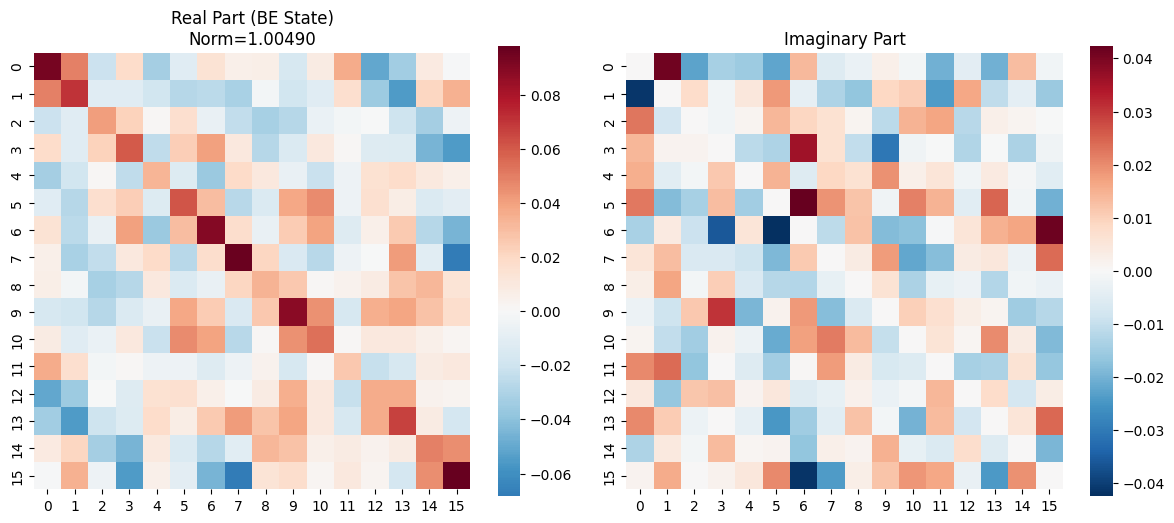


 矩阵已保存至: BE_State_4x4_rank4.npy
读取方法: rho = np.load('BE_State_4x4_rank4.npy')

 最终 PPT 检查: Min Eig = 0.000000260
✅ 这是一个合格的 PPT 态。


In [ ]:
import torch
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns

# ================= 配置 =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64) 
np.set_printoptions(threshold=sys.maxsize, linewidth=200, precision=5, suppress=True)

print(f"Running on: {device}")

TASK_DIM = 4           # 量子比特维度 (2-10)
TASK_RANK = 4          # Ansatz秩
TASK_MAX_ATTEMPTS = 20 # 最大尝试次数

# ================= 基础函数 =================

def get_ansatz_hybrid(dim, rank):
    """
    混合初始化：
    不仅仅是随机，而是让初始态稍微接近 Mixed State (I/d)，
    这样离 PPT 区域更近，减少优化难度。
    """
    # 随机部分
    real = torch.randn(dim * dim, rank, device=device)
    imag = torch.randn(dim * dim, rank, device=device)
    A_rand = torch.complex(real, imag)
    
    # 单位矩阵部分 (Reshape 成列向量形式混合)
    # 这相当于给 ansatz 加一个 bias，使其不过于极端
    bias = torch.eye(dim * dim, rank, device=device) * 0.5
    
    A = A_rand + bias
    A.requires_grad = True
    return A

def get_rho(A):
    rho_un = A @ A.mH
    trace = torch.trace(rho_un) + 1e-16
    return rho_un / trace

def partial_transpose(rho, dim):
    rho_reshaped = rho.view(dim, dim, dim, dim)
    rho_pt = rho_reshaped.permute(0, 3, 2, 1).contiguous()
    return rho_pt.view(dim * dim, dim * dim)

def get_metrics_high_dim(rho, dim):
    """
    针对高维的指标计算
    返回: 
    1. min_eig: 最小特征值 (用于最终判断)
    2. negativity_sum: 所有负特征值之和 (用于提供更强的梯度)
    3. r_norm: 重排范数
    """
    # PPT 相关
    pt = partial_transpose(rho, dim)
    eigvals = torch.linalg.eigvalsh(pt)
    
    min_eig = torch.min(eigvals)
    # 计算所有负特征值的平方和 (作为 Loss 梯度更平滑)
    # 或者直接用 sum(abs(negative_eigs))
    negatives = eigvals[eigvals < 0]
    negativity_loss = torch.sum(torch.square(negatives)) 
    
    # Entanglement 相关
    rho_reshaped = rho.view(dim, dim, dim, dim)
    rho_r = rho_reshaped.permute(0, 2, 1, 3).contiguous().view(dim*dim, dim*dim)
    r_norm = torch.linalg.matrix_norm(rho_r, ord='nuc')
    
    return min_eig, negativity_loss, r_norm

# ================= 修复函数 =================
def try_repair_state(rho_np, dim):
    print("   >>> [Auto-Repair] 启动微量白噪声混合...")
    d2 = dim * dim
    I = np.eye(d2) / d2
    
    rho_tensor = rho_np.reshape(dim, dim, dim, dim)
    rho_pt = rho_tensor.transpose(0, 3, 2, 1).reshape(d2, d2)
    min_eig = np.min(np.linalg.eigvalsh(rho_pt))
    
    if min_eig >= 0: return rho_np
    
    # 动态计算需要的噪声比例
    p_needed = abs(min_eig) * d2 * 1.2 # 给 1.2 倍余量
    print(f"   >>> 需要混合 p = {p_needed:.8f}")
    
    rho_repaired = (1 - p_needed) * rho_np + p_needed * I
    return rho_repaired

# ================= 核心：高维优化器 =================
def solve_high_dim(dim=TASK_DIM, rank=TASK_RANK, max_attempts=TASK_MAX_ATTEMPTS):
    print(f"\n⚡ 启动高维攻坚: Dim {dim}x{dim}, Rank {rank}")
    print("策略: 全局 Negativity 优化 + 混合初始化 + 长程退火")

    for attempt in range(1, max_attempts + 1):
        A = get_ansatz_hybrid(dim, rank)
        
        # 使用 AdamW，增加一点权重衰减防止过拟合
        optimizer = torch.optim.AdamW([A], lr=0.005, weight_decay=1e-5)
        
        # [改进3] 增加步数，高维需要更久收敛
        total_steps = 25000 
        
        # 学习率调度
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=0.0001)
        
        print(f"\n[Attempt {attempt}/{max_attempts}]")
        
        best_candidate = None
        best_score = -float('inf')
        
        # 目标设定：d=8 时，最大 Norm 是 8。
        # 我们不需要那么大，只要 > 1 即可。
        # 但为了防止掉下去，初始目标设高一点。
        start_target = 1.05
        end_target = 1.0002
        
        for i in range(total_steps):
            optimizer.zero_grad()
            rho = get_rho(A)
            
            min_eig, neg_loss, r_norm = get_metrics_high_dim(rho, dim)
            
            # --- 保存最佳候选 (用于修复) ---
            # 条件放宽：PPT > -0.002, Norm > 1.005
            if min_eig.item() > -0.002 and r_norm.item() > 1.005:
                score = r_norm.item() - 1000 * abs(min_eig.item())
                if score > best_score:
                    best_score = score
                    best_candidate = rho.detach().cpu().numpy()
            
            # --- 动态 Loss ---
            progress = i / total_steps
            
            # 1. 目标 Norm 衰减
            current_target = end_target + (start_target - end_target) * np.exp(-5 * progress)
            
            # 2. PPT 权重 (随时间指数增加)
            # d=8 时负特征值很难消，权重给大一点
            ppt_weight = 5000.0 + progress * 45000.0
            
            loss = 0
            
            # [关键] 使用 neg_loss (所有负值的平方和) 而不是 min_eig
            # 这样梯度会同时优化所有负方向
            loss += neg_loss * ppt_weight
            
            # 3. 纠缠维持
            if r_norm < current_target:
                diff = current_target - r_norm
                ent_weight = 200.0 + progress * 800.0
                loss += diff * ent_weight
            
            # 4. 辅助项：最大化 Norm (弱)
            # 在 PPT 还没满足时，给一点推力让它往 entangled 区域跑
            if min_eig > -0.01:
                loss += -r_norm * 0.05 
            
            loss.backward()
            optimizer.step()
            scheduler.step()
            
            # --- 判定 ---
            if min_eig.item() > -1e-8 and r_norm.item() > 1.00001:
                print(f"\n🎉 [DIRECT HIT] Step {i}")
                return rho.detach().cpu().numpy()
            
            if i % 2000 == 0:
                print(f"   Step {i:5d} | Target: {current_target:.5f} | PPT_Min: {min_eig.item():.6f} | Norm: {r_norm.item():.6f}")
                
            # 提前止损：如果 Norm 掉到 0.99 以下，说明方向彻底错了
            if r_norm.item() < 0.99:
                break
        
        # 尝试修复
        if best_candidate is not None:
            rho_fixed = try_repair_state(best_candidate, dim)
            # 验证
            rho_t = torch.tensor(rho_fixed, device=device)
            m_eig, _, m_norm = get_metrics_high_dim(rho_t, dim)
            print(f"   >>> 修复结果: PPT={m_eig.item():.8f}, Norm={m_norm.item():.8f}")
            
            if m_eig.item() > -1e-15 and m_norm.item() > 1.0:
                print("🎉 [REPAIR SUCCESS]")
                return rho_fixed
            else:
                print("   >>> 修复失败 (纠缠度不足以抵消噪声)")
        else:
            print("   >>> 无有效候选者")

    print("\n💀 All attempts failed.")
    return None

# ================= 运行 =================

target_dim = TASK_DIM
target_rank = TASK_RANK

rho_final = solve_high_dim(target_dim, target_rank, max_attempts=TASK_MAX_ATTEMPTS)

if rho_final is not None:
    print("\n" + "="*50)
    print("最终验证报告")
    print("="*50)
    
    rho_np = rho_final
    dim = target_dim
    
    # 1. PPT Check
    rho_ts = rho_np.reshape(dim, dim, dim, dim)
    rho_pt = rho_ts.transpose(0, 3, 2, 1).reshape(dim*dim, dim*dim)
    min_eig = np.min(np.linalg.eigvalsh(rho_pt))
    
    # 2. Entanglement Check
    rho_r = rho_ts.transpose(0, 2, 1, 3).reshape(dim*dim, dim*dim)
    r_norm = np.sum(np.linalg.svd(rho_r, compute_uv=False))
    
    # 3. Rank Check
    s = np.linalg.svd(rho_np, compute_uv=False)
    eff_rank = np.sum(s > 1e-4) # 稍微放宽阈值以过滤白噪声
    
    print(f"Dimension: {dim}x{dim}")
    print(f"PPT Min Eig: {min_eig:.9f}  [{'PASS' if min_eig > -1e-9 else 'FAIL'}]")
    print(f"Realignment: {r_norm:.9f}  [{'PASS' if r_norm > 1.0 else 'FAIL'}]")
    print(f"Approx Rank: {eff_rank}          (Target {target_rank})")
    
    if min_eig > -1e-9 and r_norm > 1.0:
        print("\n🏆 成功构造高维束缚纠缠态！")
        # 保存
        np.save(f"../data/TASK2_FILE_MAP/BE_State_d{dim}_r{target_rank}.npy", rho_np)
        print("矩阵已保存。")
    else:
        print("\n⚠️ 验证未完全通过。")

# ==========================================
# 1. 文本打印 (格式化输出)
# ==========================================
print("\n" + "="*50)
print("密度矩阵数值展示")
print("="*50)

# 设置打印选项：不省略，保留4位小数，一行显示更多
np.set_printoptions(threshold=np.inf, linewidth=200, precision=4, suppress=True)

# 打印实部
print("--- 实部 (Real Part) ---")
print(rho_np.real)

# 打印虚部 (如果有显著值)
if np.max(np.abs(rho_np.imag)) > 1e-5:
    print("\n--- 虚部 (Imaginary Part) ---")
    print(rho_np.imag)
else:
    print("\n(虚部几乎为0，忽略不计)")

# ==========================================
# 2. 可视化 (Cityscape/Heatmap)
# ==========================================
plt.figure(figsize=(12, 5))

# 实部热力图
plt.subplot(1, 2, 1)
sns.heatmap(rho_np.real, cmap="RdBu_r", center=0, square=True)
plt.title(f"Real Part (BE State)\nNorm={1.0049:.5f}")

# 虚部热力图
plt.subplot(1, 2, 2)
sns.heatmap(rho_np.imag, cmap="RdBu_r", center=0, square=True)
plt.title("Imaginary Part")

plt.tight_layout()
plt.show()

#保存到文件

filename = f"../data/BE_States_Results/BE_State_{TASK_DIM}x{TASK_DIM}_rank{TASK_RANK}.npy"
np.save(filename, rho_np)
print(f"\n 矩阵已保存至: {filename}")
print(f"读取方法: rho = np.load('{filename}')")

# 验证是否为 PPT (再次确认)
def check_ppt(rho):
    dim = int(np.sqrt(rho.shape[0]))
    rho_tensor = rho.reshape(dim, dim, dim, dim)
    # 对第二个子系统 (B) 进行转置 (索引 1, 3)
    rho_pt = rho_tensor.transpose(0, 3, 2, 1).reshape(dim*dim, dim*dim)
    min_eig = np.min(np.linalg.eigvalsh(rho_pt))
    return min_eig

ppt_val = check_ppt(rho_np)
print(f"\n 最终 PPT 检查: Min Eig = {ppt_val:.9f}")
if ppt_val > -1e-6:
    print("✅ 这是一个合格的 PPT 态。")
else:
    print("⚠️ 警告：仍有微小负特征值，可能需要更多白噪声混合。")

## 检验Bound State是否满足物理性质

🔬 正在分析 4x4 维量子态 (Matrix: 16x16)...

1️⃣  [PPT 判据] 部分转置最小特征值: 0.000000260
    -> 结果: ✅ PPT (正部分转置)
    -> 含义: 该态不可被提纯。

2️⃣  [CCN 判据] 重排范数 (Target > 1): 1.153297713
    -> 结果: ✅ 确认纠缠

🏆 最终结论: 这是一个【束缚纠缠态】! 🏆


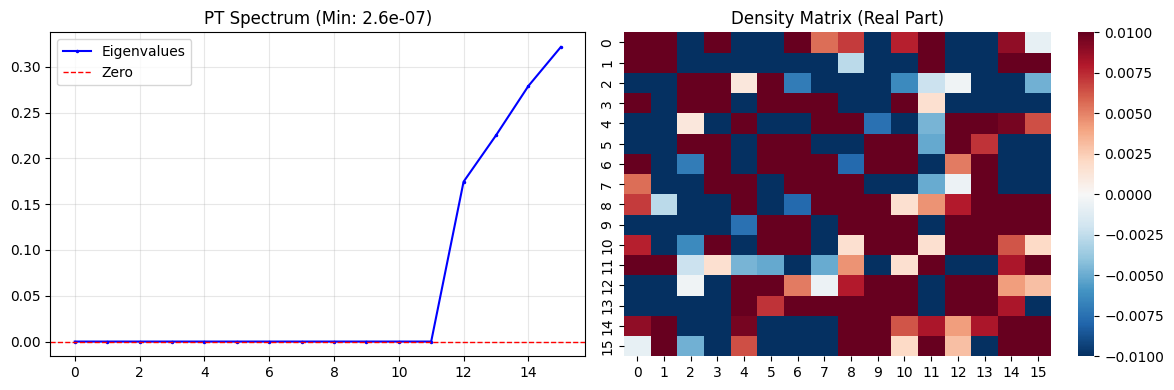

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

def check_bound_entanglement_in_notebook():
    # ================= 配置区 =================
    try:
        # 优先使用 rho_final，如果它是None或不存在，尝试使用 rho_np
        if 'rho_final' in globals() and rho_final is not None:
            rho_input = rho_final
        elif 'rho_np' in globals() and rho_np is not None:
            rho_input = rho_np
        else:
            print("❌ 错误：未找到生成的密度矩阵变量 (rho_final 或 rho_np)。请先运行生成代码。")
            return

        # 获取维度
        if 'target_dim' in globals():
            d = target_dim
        else:
            # 尝试自动推断维度
            d = int(np.sqrt(rho_input.shape[0]))
            print(f"⚠️ 未找到 target_dim 变量，自动推断维度为 d={d}")
            
    except Exception as e:
        print(f"❌ 读取数据时出错: {e}")
        return
    # ==========================================

    print(f"🔬 正在分析 {d}x{d} 维量子态 (Matrix: {d**2}x{d**2})...\n")

    # 1. 格式标准化 (Tensor -> Numpy, 厄米化, 归一化)
    if isinstance(rho_input, torch.Tensor):
        rho = rho_input.detach().cpu().numpy()
    else:
        rho = np.array(rho_input, copy=True)
    
    # 强行厄米化 (消除计算误差)
    rho = (rho + rho.conj().T) / 2
    # 强行归一化
    rho = rho / np.trace(rho)

    d2 = d * d
    tolerance = 1e-9 # 浮点数容差


    #  判据 A: PPT (Positive Partial Transpose)

    # 逻辑: 如果 min_eig < 0，则是NPT(自由纠缠)。如果 >= 0，则是PPT(可能是束缚纠缠)。
    rho_tensor = rho.reshape(d, d, d, d)
    # 转置子系统B (交换下标 1, 3)
    rho_pt = rho_tensor.transpose(0, 3, 2, 1).reshape(d2, d2)
    pt_evals = np.linalg.eigvalsh(rho_pt)
    min_pt_eig = np.min(pt_evals)

    is_ppt = min_pt_eig >= -tolerance


    # 判据 B: CCN (Computable Cross Norm / Realignment)
    # 逻辑: 如果 CCN > 1，则一定是纠缠的。
    # 重排: indices (i, j, k, l) -> (i, k, j, l)
    rho_r = rho_tensor.transpose(0, 2, 1, 3).reshape(d2, d2)
    # 计算奇异值之和 (Trace Norm)
    singular_values = np.linalg.svd(rho_r, compute_uv=False)
    ccn_norm = np.sum(singular_values)

    is_entangled = ccn_norm > 1.0 + tolerance


    #  输出结果报告

    print(f"1️⃣  [PPT 判据] 部分转置最小特征值: {min_pt_eig:.9f}")
    if is_ppt:
        print("    -> 结果: ✅ PPT (正部分转置)")
        print("    -> 含义: 该态不可被提纯。")
    else:
        print("    -> 结果: ❌ NPT (负部分转置)")
        print("    -> 含义: 该态是自由纠缠态 (Free Entangled)，不是束缚纠缠。")

    print(f"\n2️⃣  [CCN 判据] 重排范数 (Target > 1): {ccn_norm:.9f}")
    if is_entangled:
        print("    -> 结果: ✅ 确认纠缠")
    else:
        print("    -> 结果: ❓ 未检测到纠缠 (可能为可分态)")

    print("\n" + "="*40)
    if is_ppt and is_entangled:
        print("🏆 最终结论: 这是一个【束缚纠缠态】! 🏆")
    elif not is_ppt:
        print("结论: 这是一个【自由纠缠态】 (NPT Entangled)。")
    else:
        print("结论: 无法确认纠缠 (可能是PPT可分态)。")
    print("="*40)


    # 可视化绘图

    plt.figure(figsize=(12, 4))
    
    # 图1: 部分转置谱 (PT Eigenvalues)
    plt.subplot(1, 2, 1)
    plt.plot(pt_evals, 'b.-', markersize=3, label='Eigenvalues')
    plt.axhline(0, color='r', linestyle='--', linewidth=1, label='Zero')
    plt.title(f"PT Spectrum (Min: {min_pt_eig:.1e})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    if min_pt_eig < 0:
        # 如果有负值，放大显示负值区域
        plt.ylim(min_pt_eig * 1.5, abs(min_pt_eig) * 1.5)
        plt.title(f"PT Spectrum (Zoomed on Negative)")

    # 图2: 密度矩阵实部
    plt.subplot(1, 2, 2)
    # 为了显示清晰，取对数或者限制范围
    sns.heatmap(rho.real, cmap="RdBu_r", center=0, vmin=-0.01, vmax=0.01)
    plt.title("Density Matrix (Real Part)")
    
    plt.tight_layout()
    plt.show()

# 运行检验
check_bound_entanglement_in_notebook()